In [3]:
from pathlib import Path
import os

DATAPATH = Path("./ebola_data").resolve()
os.environ["DATAPATH"] = str(DATAPATH)
print(f"DATAPATH set to: {DATAPATH}")

DATAPATH set to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data


In [4]:
# loop over all fasta files in the data directory and run cd-hit to cluster sequences at 90% identity
run_cdhit = False
if run_cdhit == True:
	for fasta_file in DATAPATH.glob("*.fasta"):
		output_file = fasta_file.with_name(f"{fasta_file.stem}_cdhit.fasta")
		os.system(f"cd-hit -i {fasta_file} -o {output_file} -c 0.9 -n 5")

In [5]:
%%bash
set -euo pipefail

MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
INPUT_DIR="$DATAPATH/"
OUTPUT_ROOT="$DATAPATH/ebola_protfams"

mkdir -p "$OUTPUT_ROOT"

find "$INPUT_DIR" -maxdepth 1 -type f \( -name "*.fa" -o -name "*.fasta" -o -name "*.faa" \) | while read -r aa_fasta; do
	fname="$(basename "$aa_fasta")"
	stem="${fname%.*}"
	out_dir="$OUTPUT_ROOT/$stem"
	mkdir -p "$out_dir"

	db_name="${stem}_foldseekdb"
	output_db="$out_dir/$db_name"

	python -m esm3di.fastas2foldseekdb \
		--aa-fasta "$aa_fasta" \
		--model-ckpt "$MODEL_CKPT" \
		--output-db "$output_db" \
		--num-gpus 1 \
		--revision 46c5f7d \
		--keep-fastas
done

Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_GP.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using model revision: 46c5f7d
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small


Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 2290.17it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.weight | MISSING | 
classifier.{0, 2, 3}.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


...

Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 1962.69it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.bias   | MISSING | 
classifier.{0, 2, 3}.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Processed 40/108 sequences
Processed 80/108 sequences
Processed 108/108 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ Prediction complete! 108 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb
Total sequences: 108
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb, size: 235927 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L_cdhit/Ebola_L_cdhit_foldseekdb_ss, size: 235927 bytes
Header file: /home/dmoi/projects/ESM3

In [6]:
#run 3di prediction on the clustered fasta files

In [7]:
import glob
#check if the output files exist
output_files = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.index")
if len(output_files) == 0:
	raise FileNotFoundError("No output .index files were created. Please check the previous steps for errors.")

In [8]:
#create a foldtree for each family

import os
import glob
import subprocess

def runFoldseek_allvall( dbpath , outfolder , foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	dbpath : str
		path to foldseek database
	outfolder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(outfolder):
		os.makedirs(outfolder)
	dbfolder = os.path.dirname(dbpath)

	cmd = foldseekpath + " easy-search " + dbpath + " "+ dbpath +" "+ outfolder+"/allvall.csv " +  dbfolder+"/tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' --exhaustive-search --alignment-type 2" 
	subprocess.run(cmd, shell=True, check=True)
	
	return outfolder +'aln_score.tsv'

protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	db_path = db_path.replace('_ss', '')  # Ensure the path uses forward slashes
	
	output_folder = os.path.join(folder, "foldseek_results")
	print(f"Running foldseek for {db_path}...")
	if not os.path.exists(os.path.join(output_folder, "allvall.csv")):  # Check if results already exist	
		runFoldseek_allvall(db_path, output_folder)
		print(f"Results saved in {output_folder}.")
	else:
		print(f"Results already exist in {output_folder}. Skipping foldseek run.")


Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/Ebola_GP_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/Ebola_GP_cdhit_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/foldseek_results. Skipping foldseek run.
Running foldseek for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/Ebola_NP_foldseekdb...
Results already exist in /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola

In [9]:
import shlex
def runQuicktree(   clusterfile , quicktreepath= 'quicktree' ):
	'''
	run quicktree

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	quicktreepath : str 
		path to quicktree binary

	'''
	args = quicktreepath + ' -i m ' + clusterfile +' > ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


def runFastme(   clusterfile , fastmepath= 'fastme' ):
	'''
	run fastme

	parameters
	----------
	clusterfile : str
		path to all vs all distance matrix in fastme format
	fastmepath : str 
		path to fastme binary

	'''
	args = fastmepath + ' -i ' + clusterfile +' -o ' + clusterfile + '.struct_tree.nwk'
	print(args)
	p =subprocess.run(args , shell= True)
	return clusterfile + '.struct_tree.nwk'


In [10]:
#finish up 
import sys
import os
import pandas as pd
import numpy as np
import tqdm
from matplotlib import pyplot as plt

run_trees= False


foldtree_dir = '/home/dmoi/projects/fold_tree'
fastmepath = 'fastme'
delta = 1e-5

sys.path.append(foldtree_dir)
import foldtree.foldseek2tree as ft1

if run_trees == True:
	for folder in protfam_folders:
		alnres = f"{folder}/foldseek_results/allvall.csv"
		res = pd.read_table(alnres , header = None )
		res[0] = res[0].map(lambda x :x.replace('.pdb', ''))
		res[1] = res[1].map(lambda x :x.replace('.pdb', ''))
		res.columns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
		#drop rows where query and target are the same
		res = res[res['query'] != res['target']]
		
		res.fident.hist(bins = 100)
		plt.show()
		ids = list( set(list(res['query'].unique()) + list(res['target'].unique())))
		pos = { protid : i for i,protid in enumerate(ids)}
		kernels = ['fident']
		matrices = { k:np.zeros((len(pos), len(pos))) for k in kernels }
		print(res)

		#calc kernel for tm, aln score, lddt
		for idx,row in tqdm.tqdm(res.iterrows(), total=res.shape[0]):
			for k in matrices:
				matrices[k][pos[row['query']] , pos[row['target']]] += row[k]
				matrices[k][pos[row['target']] , pos[row['query']]] += row[k]

		trees = {}
		for i,k in enumerate(matrices):
			matrices[k] /= 2
			matrices[k] = 1-matrices[k]
			matrices[k][np.diag_indices_from(matrices[k])] = 0
			#floor at 0.0001 to avoid issues with fastme
			matrices[k][matrices[k] < delta] = delta
			

			if k == 'fident':
				distmat = ft1.Tajima_dist( matrices[k] , bfactor = .93 , iter = 100 )
			else:
				distmat = ft1.Tajima_dist( matrices[k] )
			print(distmat,  np.amax(distmat), np.amin(distmat) )

			#save the distance matrix and run fastme to the same folder as the input csv file
			np.save( os.path.join(folder, k + '_distmat.npy') , distmat)
			distmat_txt = ft1.distmat_to_txt( ids , distmat , os.path.join(folder, k + '_distmat.txt') )
			treefile = ft1.runQuicktree( clusterfile=distmat_txt )
			out_tree = ft1.postprocess(treefile, treefile+'.pp.nwk' , delta = delta)
			trees[k] = out_tree
			

/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [11]:
import os
from typing import Dict, List, Optional

from Bio import Entrez

def _extract_tax_id_from_feature_table(feature_table: List[dict]) -> str:
    """Extract NCBI taxon ID from GenBank feature qualifiers."""
    for feature in feature_table or []:
        for qualifier in feature.get("GBFeature_quals", []) or []:
            if qualifier.get("GBQualifier_name") != "db_xref":
                continue
            value = qualifier.get("GBQualifier_value", "")
            if value.startswith("taxon:"):
                return value.split(":", 1)[1]
    return ""


def fetch_taxonomic_info(
    accessions: List[str],
    batch_size: int = 10,
    seq_type: str = "nucleotide",
    email: Optional[str] = None,
    api_key: Optional[str] = None,
) -> Dict[str, Dict]:
    """
    Fetch taxonomic information for a list of accessions using NCBI Entrez.
    
    Args:
        accessions: List of NCBI accession numbers
        batch_size: Number of accessions to fetch per batch (default: 10)
        seq_type: Type of sequence - "nucleotide" or "protein" (default: "nucleotide")
        email: Entrez contact email. Defaults to NCBI_EMAIL env var when omitted.
        api_key: NCBI API key. Defaults to NCBI_API_KEY env var when omitted.
        
    Returns:
        Dictionary with accession as key and taxonomic info as value
    """
    
    Entrez.email = email or os.environ.get("NCBI_EMAIL", "dmoi@unil.ch")
    Entrez.api_key = api_key or os.environ.get("NCBI_API_KEY")
    
    # Map sequence type to NCBI database
    db_map = {"nucleotide": "nucleotide", "protein": "protein"}
    db = db_map.get(seq_type.lower(), "nucleotide")
    
    taxonomic_info = {}
    
    # Process accessions in batches
    for i in tqdm.tqdm(range(0, len(accessions), batch_size)):
        batch = accessions[i:i + batch_size]
        
        try:
            # Accession identifiers belong to sequence DBs, not the taxonomy DB.
            accession_ids = ",".join(batch)
            handle = Entrez.efetch(db=db, id=accession_ids, rettype="gb", retmode="xml")
            records = Entrez.read(handle)
            handle.close()

            found = set()
            for record in records:
                acc_version = record.get("GBSeq_accession-version", "")
                primary = record.get("GBSeq_primary-accession", "")
                accession_key = acc_version or primary
                if not accession_key:
                    continue

                normalized_candidates = {accession_key, primary, accession_key.split(".")[0]}
                matched_accession = next((a for a in batch if a in normalized_candidates), accession_key)

                taxonomic_info[matched_accession] = {
                    "accession": accession_key,
                    "tax_id": _extract_tax_id_from_feature_table(record.get("GBSeq_feature-table", [])),
                    "organism": record.get("GBSeq_organism", ""),
                    "scientific_name": record.get("GBSeq_organism", ""),
                    "taxonomy": record.get("GBSeq_taxonomy", ""),
                    "lineage": record.get("GBSeq_taxonomy", ""),
                    "division": record.get("GBSeq_division", ""),
                }
                found.add(matched_accession)

            for accession in batch:
                if accession not in found and accession not in taxonomic_info:
                    taxonomic_info[accession] = {
                        "error": "No sequence record found for accession in requested DB",
                        "db": db,
                    }

        except Exception as e:
            for accession in batch:
                taxonomic_info[accession] = {"error": str(e)}
    
    return taxonomic_info


# Example usage:
if __name__ == "__main__":
    accessions = ["NC_001802", "NC_045512.2"]  # Example nucleotide accessions
    result = fetch_taxonomic_info(accessions, seq_type="nucleotide")

    for acc, info in result.items():
        print(f"Accession: {acc}")
        print(f"Organism: {info.get('organism')}")
        print(f"Taxonomy: {info.get('taxonomy')}")
        print(f"TaxID: {info.get('tax_id')}")
        print()


100%|██████████| 1/1 [00:00<00:00,  1.29it/s]

Accession: NC_001802
Organism: Human immunodeficiency virus 1
Taxonomy: Viruses; Riboviria; Pararnavirae; Artverviricota; Revtraviricetes; Ortervirales; Retroviridae; Orthoretrovirinae; Lentivirus; Lentivirus humimdef1
TaxID: 11676

Accession: NC_045512.2
Organism: Severe acute respiratory syndrome coronavirus 2
Taxonomy: Viruses; Riboviria; Orthornavirae; Pisuviricota; Pisoniviricetes; Nidovirales; Cornidovirineae; Coronaviridae; Orthocoronavirinae; Betacoronavirus; Sarbecovirus; Betacoronavirus pandemicum
TaxID: 2697049



In [18]:
#run find this for all accessions in the input fasta files and save the results to a csv file
import glob
import os

overwrite_taxonomic_info = False
for fasta in glob.glob(f"{DATAPATH}/*.fasta"):
	accessions = []
	with open(fasta, 'r') as f:
		for line in f:
			if line.startswith('>'):
				accession = line[1:].strip().split()[0]
				accessions.append(accession)
	output_csv = os.path.splitext(fasta)[0] + "_taxonomic_info.csv"
	if overwrite_taxonomic_info or not os.path.exists(output_csv):
		taxonomic_info = fetch_taxonomic_info(accessions, seq_type="protein")

		df = pd.DataFrame.from_dict(taxonomic_info, orient='index')
		df.to_csv(output_csv)
		print(f"Taxonomic information saved to {output_csv}")
	else:
		print("Skipping taxonomic information retrieval.")


#load the taxonomic information from the csv files and merge them into a single dataframe
import pandas as pd
taxonomic_info_dfs = []
for csv_file in glob.glob(f"{DATAPATH}/*_taxonomic_info.csv"):
	df = pd.read_csv(csv_file, index_col=0)
	taxonomic_info_dfs.append(df)
merged_taxdata_df = pd.concat(taxonomic_info_dfs)
print(f"Combined taxonomic information dataframe shape: {merged_taxdata_df.shape}")
print(merged_taxdata_df.head())


Skipping taxonomic information retrieval.
Skipping taxonomic information retrieval.
Skipping taxonomic information retrieval.
Skipping taxonomic information retrieval.
Skipping taxonomic information retrieval.
Skipping taxonomic information retrieval.
Combined taxonomic information dataframe shape: (10095, 8)
             accession     tax_id                       organism  \
AAA42977.1  AAA42977.1   186538.0               Zaire ebolavirus   
AAA46563.1  AAA46563.1  3052505.0  Orthomarburgvirus marburgense   
BAB69003.1  BAB69003.1   129003.0     Reston ebolavirus - Reston   
AAU43883.1  AAU43883.1   186540.0               Sudan ebolavirus   
ACI28620.1  ACI28620.1   565995.0               Bundibugyo virus   

                          scientific_name  \
AAA42977.1               Zaire ebolavirus   
AAA46563.1  Orthomarburgvirus marburgense   
BAB69003.1     Reston ebolavirus - Reston   
AAU43883.1               Sudan ebolavirus   
ACI28620.1               Bundibugyo virus   

         

In [19]:
#find all trees and save them to a new folder
import shutil
trees = glob.glob(f"{DATAPATH}/ebola_protfams/*/*.pp.nwk") + glob.glob(f"{DATAPATH}/ebola_protfams_cdhit/*/*.pp.nwk")
print(trees)
output_tree_folder = os.path.join(DATAPATH, "ebola_trees")
if not os.path.exists(output_tree_folder):
	os.makedirs(output_tree_folder)
#copy all trees to the new folder
for tree in trees:
	fam_nam = tree.split('/')[-2]
	tree_name = os.path.basename(tree)
	output_tree_path = os.path.join(output_tree_folder, f"{fam_nam}_{tree_name}")
	if not os.path.exists(output_tree_path):
		shutil.copy(tree, output_tree_path)
		print(f"Copied {tree} to {output_tree_path}")
	else:
		print(f"{output_tree_path} already exists. Skipping copy.")

['/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_NP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_GP_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk', '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_cdhit/Ebola_L_cdhit/fident_distmat.txt.struct_tree.nwk.pp.nwk']
/home/dmo

In [ ]:
#load all trees and plot them using toytree
import toytree
import glob
import os
import colour
	
ebola_tree_folder = os.path.join(DATAPATH, "ebola_trees")
for tree in glob.glob(f"{ebola_tree_folder}/*.pp.nwk"):
	if 'cdhit' in tree:
		for tax_level in range(8, 11):
			tre = toytree.tree(tree)
			#find all rows in the merged taxdata_df that have the same tax_id and group them together
			subdf = merged_taxdata_df[merged_taxdata_df['accession'].isin(tre.get_tip_labels())]
			print(f"Tree {tree} has {len(tre.get_tip_labels())} tips and {len(subdf)} matching taxonomic entries.")
			#select a taxonomic level to group by with a number
			subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
			subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
			#choose a color for each tiplabel
			red = colour.Color("red")
			blue = colour.Color("blue")
			colors = list(red.range_to(blue, len(subdf['tiplabel'].unique())))

			#change to hex strings
			colors = [color.hex_l for color in colors]

			color_map = {label: color for label, color in zip(subdf['tiplabel'].unique(), colors)}
			tiplabel_colors = color_map
			print(f"Tip label colors for taxonomic level {tax_level}: {tiplabel_colors}")
			#map each tip's tax_id to its taxonomic label at the chosen level, so tips can be annotated directly

			tipid_to_label = subdf.set_index('accession')['tiplabel'].to_dict()
			print(f"Tip ID to label mapping for taxonomic level {tax_level}: {tipid_to_label}")

			tip_ids = tre.get_tip_labels()
			tip_labels_text = [f"{tid} | {tipid_to_label.get(tid, 'unknown')}" for tid in tip_ids]
			tip_colors = [tiplabel_colors.get(tipid_to_label.get(tid), '#000000') for tid in tip_ids]

			print( tip_colors)
			#tip nodes come first (idx 0..ntips-1); color those by tax label, keep internal nodes black
			n_internal = tre.nnodes - tre.ntips
			node_colors = tip_colors + ['black'] * n_internal
			#derive a readable title from the tree filename (family name)
			tree_title = os.path.basename(tree).replace('.pp.nwk', '').replace('_', ' ')
			#display the tree with the tip text showing the tax level name, colored by that same taxonomic level
			canvas, axes, mark = tre.draw(tip_labels=tip_labels_text, tip_labels_color=tip_colors, node_sizes=5, node_colors=node_colors, edge_colors='black', width=900, height=600, show_node_labels=False, label=f"{tree_title} — Taxonomic Level {tax_level}")
			#legend mapping each taxonomic label at this level to its color, using toyplot's legend API
			legend_entries = [(str(label), "rect", {"fill": color}) for label, color in tiplabel_colors.items() if label is not None]
			#if legend_entries:
			#	canvas.legend(legend_entries, corner=("right", 20, 150, max(20, min(300, 20 * len(legend_entries)))))

#choose a tax level


/tmp/ipykernel_1810274/2108589388.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
/tmp/ipykernel_1810274/2108589388.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have 

/tmp/ipykernel_1810274/2108589388.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
/tmp/ipykernel_1810274/2108589388.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have 

Tree /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/Ebola_GP_cdhit_fident_distmat.txt.struct_tree.nwk.pp.nwk has 74 tips and 148 matching taxonomic entries.
Tip label colors for taxonomic level 8: {' Orthomarburgvirus': '#ff0000', ' Orthoebolavirus': '#ffaa00', ' Thamnovirus': '#aaff00', ' Dianlovirus': '#00ff00', ' Oblavirus': '#00ffaa', None: '#00aaff', ' Loebevirus': '#0000ff'}
Tip ID to label mapping for taxonomic level 8: {'CAA78117.1': ' Orthomarburgvirus', 'AAB81004.1': ' Orthoebolavirus', 'AAC54882.1': ' Orthoebolavirus', 'AAC54885.1': ' Orthoebolavirus', 'AAB37093.1': ' Orthoebolavirus', 'AAC40459.1': ' Orthomarburgvirus', 'ACI28624.1': ' Orthoebolavirus', 'AKC35933.1': ' Orthoebolavirus', 'AKC35951.1': ' Orthoebolavirus', 'AKC36032.1': ' Orthoebolavirus', 'AKC36410.1': ' Orthoebolavirus', 'AKC37129.1': ' Orthoebolavirus', 'AKI83423.1': ' Orthoebolavirus', 'ALB07126.1': ' Orthoebolavirus', 'AMY60255.1': ' Orthoebolavirus', 'AMY60345.1': ' Orthoebolavirus', 'AND81

/tmp/ipykernel_1810274/2108589388.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['levels'] = subdf['taxonomy'].map(lambda x: x.split(';'))
/tmp/ipykernel_1810274/2108589388.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['tiplabel'] = subdf['levels'].map(lambda x: x[tax_level] if len(x) > tax_level else None)
⚠️ toytree | draw_toytree:get_tree_style_updated_by_draw_args | Unrecognized arguments skipped: ['tip_labels_color', 'show_node_labels'].
Check the docs, argument names may have 

Tree /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_trees/Ebola_NP_cdhit_fident_distmat.txt.struct_tree.nwk.pp.nwk has 66 tips and 132 matching taxonomic entries.
Tip label colors for taxonomic level 10: {None: '#ff0000'}
Tip ID to label mapping for taxonomic level 10: {'AAA42977.1': None, 'AAA46563.1': None, 'BAB69003.1': None, 'AAU43883.1': None, 'ACI28620.1': None, 'YP_003815423.1': None, 'AER23671.1': None, 'AKC35930.1': None, 'AKC36407.1': None, 'AKG65328.1': None, 'AKU75255.1': None, 'ALB07123.1': None, 'ALG01105.1': None, 'AMY60252.1': None, 'AMY60342.1': None, 'AND81212.1': None, 'ASJ82192.1': None, 'AVM87232.1': None, 'AYP10372.1': None, 'AYP10384.1': None, 'AYP10402.1': None, 'AYP10410.1': None, 'AYP10417.1': None, 'AYP10427.1': None, 'AZL57167.1': None, 'AZL57185.1': None, 'QNL24148.1': None, 'QNL24328.1': None, 'QNL24355.1': None, 'QNL24499.1': None, 'QNL24652.1': None, 'QNL24724.1': None, 'QNL25075.1': None, 'QNL25444.1': None, 'QNL25534.1': None, 'QNL26290.1': Non

...

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="900.0px" height="600.0px" viewBox="0 0 900.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="tad2cc8e913f848859d0e1fa9b059c832"> QNL24499.1 | Orthoebolavirus zairense QNL27811.1 | Orthoebolavirus zairense QYR86843.1 | Orthoebolavirus zairense QYR86528.1 | Orthoebolavirus zairense AZL57167.1 | Orthoebolavirus zairense QNL24652.1 | Orthoebolavirus zairense AER23671.1 | None QNL28700.1 | Orthoebolavirus zairense AAA46563.1 | None YP_010798906.1 | Tapjovirus bothropis AVM87232.1 | Striavirus antennarii QYR86114.1 | Orthoebolavirus zairense QUJ10616.1 | Orthoebolavirus zairense QYR85151.1 | Orthoebolavirus zairense QNL26704.1 | Orthoebolavirus zairense AYP10427.1 | Orthoebolavirus zairense QYR86177.1 | Orthoebolavirus zairense QNL27856.1 | Orthoebolavirus zairense QNL26290.1 | Orthoebolavirus zairense QNL24148.1 | Orthoebolavirus zairense AMY60342.1 | Orthoebolavirus zairense YP_003815423.1 | Orthoebolavirus taiense ACI28620.1 | Orthoebolavirus bundibugyoense AAU43883.1 | Orthoebolavirus sudanense BAB69003.1 | Orthoebolavirus restonense ASJ82192.1 | Orthoebolavirus bombaliense AKC36407.1 | Orthoebolavirus zairense AMY60252.1 | Orthoebolavirus zairense QNL27298.1 | Orthoebolavirus zairense ALG01105.1 | Orthoebolavirus zairense AKG65328.1 | Orthoebolavirus zairense QNL26317.1 | Orthoebolavirus zairense AAA42977.1 | Orthoebolavirus zairense QYR86627.1 | Orthoebolavirus zairense QNL24724.1 | Orthoebolavirus zairense QYR85646.1 | Orthoebolavirus zairense QNL28431.1 | Orthoebolavirus zairense QYR86240.1 | Orthoebolavirus zairense QYR86861.1 | Orthoebolavirus zairense QNL27262.1 | Orthoebolavirus zairense QNL28988.1 | Orthoebolavirus zairense QNL25534.1 | Orthoebolavirus zairense QNL26497.1 | Orthoebolavirus zairense AYP10410.1 | Orthoebolavirus zairense AYP10372.1 | Orthoebolavirus zairense AYP10417.1 | Orthoebolavirus zairense AYP10402.1 | Orthoebolavirus zairense AYP10384.1 | Orthoebolavirus zairense QNL26299.1 | Orthoebolavirus zairense QNL25444.1 | Orthoebolavirus zairense AZL57185.1 | Orthoebolavirus zairense AKU75255.1 | Orthoebolavirus zairense AKC35930.1 | Orthoebolavirus zairense AND81212.1 | Orthoebolavirus zairense QNL28314.1 | Orthoebolavirus zairense QNL27730.1 | Orthoebolavirus zairense QYR85547.1 | Orthoebolavirus zairense QNL28296.1 | Orthoebolavirus zairense QNL29042.1 | Orthoebolavirus zairense QYR85439.1 | Orthoebolavirus zairense ALB07123.1 | Orthoebolavirus zairense QNL24355.1 | Orthoebolavirus zairense QNL27793.1 | Orthoebolavirus zairense QNL25075.1 | Orthoebolavirus zairense QUJ10607.1 | Orthoebolavirus zairense QNL24328.1 | Orthoebolavirus zairense Ebola NP cdhit fident distmat.txt.struct tree.nwk — Taxonomic Level 9

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="900.0px" height="600.0px" viewBox="0 0 900.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t0763fe78427e4079a6e3f217a5599cf2"> QNL24499.1 | None QNL27811.1 | None QYR86843.1 | None QYR86528.1 | None AZL57167.1 | None QNL24652.1 | None AER23671.1 | None QNL28700.1 | None AAA46563.1 | None YP_010798906.1 | None AVM87232.1 | None QYR86114.1 | None QUJ10616.1 | None QYR85151.1 | None QNL26704.1 | None AYP10427.1 | None QYR86177.1 | None QNL27856.1 | None QNL26290.1 | None QNL24148.1 | None AMY60342.1 | None YP_003815423.1 | None ACI28620.1 | None AAU43883.1 | None BAB69003.1 | None ASJ82192.1 | None AKC36407.1 | None AMY60252.1 | None QNL27298.1 | None ALG01105.1 | None AKG65328.1 | None QNL26317.1 | None AAA42977.1 | None QYR86627.1 | None QNL24724.1 | None QYR85646.1 | None QNL28431.1 | None QYR86240.1 | None QYR86861.1 | None QNL27262.1 | None QNL28988.1 | None QNL25534.1 | None QNL26497.1 | None AYP10410.1 | None AYP10372.1 | None AYP10417.1 | None AYP10402.1 | None AYP10384.1 | None QNL26299.1 | None QNL25444.1 | None AZL57185.1 | None AKU75255.1 | None AKC35930.1 | None AND81212.1 | None QNL28314.1 | None QNL27730.1 | None QYR85547.1 | None QNL28296.1 | None QNL29042.1 | None QYR85439.1 | None ALB07123.1 | None QNL24355.1 | None QNL27793.1 | None QNL25075.1 | None QUJ10607.1 | None QNL24328.1 | None Ebola NP cdhit fident distmat.txt.struct tree.nwk — Taxonomic Level 10

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="900.0px" height="600.0px" viewBox="0 0 900.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t7fd049411a044cc58a364573874f5f69"> QNL24732.1 | Orthoebolavirus QNL24156.1 | Orthoebolavirus QYR85159.1 | Orthoebolavirus QWX21695.1 | Orthoebolavirus QWX21650.1 | Orthoebolavirus QWX21722.1 | Orthoebolavirus QNL28304.1 | Orthoebolavirus WWV92540.1 | Orthoebolavirus QNL28735.1 | Orthoebolavirus QNL24165.1 | Orthoebolavirus QYR85447.1 | Orthoebolavirus AND81220.1 | Orthoebolavirus WWV92828.1 | Orthoebolavirus WWV93305.1 | Orthoebolavirus QWX21659.1 | Orthoebolavirus QNL26298.1 | Orthoebolavirus AAV48581.1 | Orthoebolavirus AAA79970.1 | Orthoebolavirus ASJ82200.1 | Orthoebolavirus ACI28627.1 | Orthoebolavirus QNC49664.1 | Orthoebolavirus QNC49574.1 | Orthoebolavirus ACI28636.1 | Orthoebolavirus QYR86032.1 | Orthoebolavirus APW30001.1 | Orthoebolavirus QNL26307.1 | Orthoebolavirus AJA04390.1 | Orthoebolavirus QNL24534.1 | Orthoebolavirus AYA82998.1 | Orthoebolavirus QYR85393.1 | Orthoebolavirus QYR86257.1 | Orthoebolavirus QNL25155.1 | Orthoebolavirus QNL27324.1 | Orthoebolavirus AZL57184.1 | Orthoebolavirus AZL57169.1 | Orthoebolavirus QNL27666.1 | Orthoebolavirus WWV92810.1 | Orthoebolavirus QNL27864.1 | Orthoebolavirus AYP10422.1 | Orthoebolavirus AYP10431.1 | Orthoebolavirus QNL27486.1 | Orthoebolavirus QNL27621.1 | Orthoebolavirus QNL26145.1 | Orthoebolavirus QNL27189.1 | Orthoebolavirus WWV92873.1 | Orthoebolavirus QNL25731.1 | Orthoebolavirus QNL25542.1 | Orthoebolavirus QYR86194.1 | Orthoebolavirus QYR86869.1 | Orthoebolavirus QYR85555.1 | Orthoebolavirus QYR86635.1 | Orthoebolavirus QYR86248.1 | Orthoebolavirus QYR86851.1 | Orthoebolavirus QYR86185.1 | Orthoebolavirus QNL28996.1 | Orthoebolavirus QNL28286.1 | Orthoebolavirus QUJ10596.1 | Orthoebolavirus QNL27171.1 | Orthoebolavirus QNL26856.1 | Orthoebolavirus QNL26253.1 | Orthoebolavirus AJZ74655.1 | Orthoebolavirus QYR86122.1 | Orthoebolavirus QNL28430.1 | Orthoebolavirus QNL24660.1 | Orthoebolavirus QNL26712.1 | Orthoebolavirus QNL24507.1 | Orthoebolavirus ASV62251.1 | Orthoebolavirus QNL27270.1 | Orthoebolavirus QNL24300.1 | Orthoebolavirus QNL24363.1 | Orthoebolavirus QNL27828.1 | Orthoebolavirus AYW17029.1 | Orthoebolavirus QNL27810.1 | Orthoebolavirus QNL27504.1 | Orthoebolavirus AJZ74690.1 | Orthoebolavirus WWV93062.1 | Orthoebolavirus QNL27630.1 | Orthoebolavirus WWV92657.1 | Orthoebolavirus WWV92747.1 | Orthoebolavirus WWV92756.1 | Orthoebolavirus WWV93233.1 | Orthoebolavirus QWX21767.1 | Orthoebolavirus AZL57232.1 | Orthoebolavirus QNL27306.1 | Orthoebolavirus QNL28519.1 | Orthoebolavirus QNL26325.1 | Orthoebolavirus QNL27738.1 | Orthoebolavirus QNL25083.1 | Orthoebolavirus QYR85654.1 | Orthoebolavirus ALP30070.1 | Orthoebolavirus QTZ17677.1 | Orthoebolavirus QYR86536.1 | Orthoebolavirus ALF04606.1 | Orthoebolavirus QNL27819.1 | Orthoebolavirus QNL28438.1 | Orthoebolavirus QNL28322.1 | Orthoebolavirus QNL25569.1 | Orthoebolavirus QNL26271.1 | Orthoebolavirus QNL25452.1 | Orthoebolavirus QNL25659.1 | Orthoebolavirus QNL24705.1 | Orthoebolavirus QNL25983.1 | Orthoebolavirus AJZ74542.1 | Orthoebolavirus AJZ74707.1 | Orthoebolavirus AJZ74681.1 | Orthoebolavirus AJZ74533.1 | Orthoebolavirus ALB07131.1 | Orthoebolavirus AMY60260.1 | Orthoebolavirus Ebola L cdhit fident distmat.txt.struct tree.nwk — Taxonomic Level 8

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="900.0px" height="600.0px" viewBox="0 0 900.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="t3ddebfa0a59948e4a990d67bc1385ae2"> QNL24732.1 | Orthoebolavirus zairense QNL24156.1 | Orthoebolavirus zairense QYR85159.1 | Orthoebolavirus zairense QWX21695.1 | Orthoebolavirus zairense QWX21650.1 | Orthoebolavirus zairense QWX21722.1 | Orthoebolavirus zairense QNL28304.1 | Orthoebolavirus zairense WWV92540.1 | Orthoebolavirus zairense QNL28735.1 | Orthoebolavirus zairense QNL24165.1 | Orthoebolavirus zairense QYR85447.1 | Orthoebolavirus zairense AND81220.1 | Orthoebolavirus zairense WWV92828.1 | Orthoebolavirus zairense WWV93305.1 | Orthoebolavirus zairense QWX21659.1 | Orthoebolavirus zairense QNL26298.1 | Orthoebolavirus zairense AAV48581.1 | Orthoebolavirus restonense AAA79970.1 | Orthoebolavirus sudanense ASJ82200.1 | Orthoebolavirus bombaliense ACI28627.1 | Orthoebolavirus bundibugyoense QNC49664.1 | Orthoebolavirus bundibugyoense QNC49574.1 | Orthoebolavirus bundibugyoense ACI28636.1 | Orthoebolavirus taiense QYR86032.1 | Orthoebolavirus zairense APW30001.1 | Orthoebolavirus zairense QNL26307.1 | Orthoebolavirus zairense AJA04390.1 | Orthoebolavirus zairense QNL24534.1 | Orthoebolavirus zairense AYA82998.1 | Orthoebolavirus zairense QYR85393.1 | Orthoebolavirus zairense QYR86257.1 | Orthoebolavirus zairense QNL25155.1 | Orthoebolavirus zairense QNL27324.1 | Orthoebolavirus zairense AZL57184.1 | Orthoebolavirus zairense AZL57169.1 | Orthoebolavirus zairense QNL27666.1 | Orthoebolavirus zairense WWV92810.1 | Orthoebolavirus zairense QNL27864.1 | Orthoebolavirus zairense AYP10422.1 | Orthoebolavirus zairense AYP10431.1 | Orthoebolavirus zairense QNL27486.1 | Orthoebolavirus zairense QNL27621.1 | Orthoebolavirus zairense QNL26145.1 | Orthoebolavirus zairense QNL27189.1 | Orthoebolavirus zairense WWV92873.1 | Orthoebolavirus zairense QNL25731.1 | Orthoebolavirus zairense QNL25542.1 | Orthoebolavirus zairense QYR86194.1 | Orthoebolavirus zairense QYR86869.1 | Orthoebolavirus zairense QYR85555.1 | Orthoebolavirus zairense QYR86635.1 | Orthoebolavirus zairense QYR86248.1 | Orthoebolavirus zairense QYR86851.1 | Orthoebolavirus zairense QYR86185.1 | Orthoebolavirus zairense QNL28996.1 | Orthoebolavirus zairense QNL28286.1 | Orthoebolavirus zairense QUJ10596.1 | Orthoebolavirus zairense QNL27171.1 | Orthoebolavirus zairense QNL26856.1 | Orthoebolavirus zairense QNL26253.1 | Orthoebolavirus zairense AJZ74655.1 | Orthoebolavirus zairense QYR86122.1 | Orthoebolavirus zairense QNL28430.1 | Orthoebolavirus zairense QNL24660.1 | Orthoebolavirus zairense QNL26712.1 | Orthoebolavirus zairense QNL24507.1 | Orthoebolavirus zairense ASV62251.1 | Orthoebolavirus zairense QNL27270.1 | Orthoebolavirus zairense QNL24300.1 | Orthoebolavirus zairense QNL24363.1 | Orthoebolavirus zairense QNL27828.1 | Orthoebolavirus zairense AYW17029.1 | Orthoebolavirus zairense QNL27810.1 | Orthoebolavirus zairense QNL27504.1 | Orthoebolavirus zairense AJZ74690.1 | Orthoebolavirus zairense WWV93062.1 | Orthoebolavirus zairense QNL27630.1 | Orthoebolavirus zairense WWV92657.1 | Orthoebolavirus zairense WWV92747.1 | Orthoebolavirus zairense WWV92756.1 | Orthoebolavirus zairense WWV93233.1 | Orthoebolavirus zairense QWX21767.1 | Orthoebolavirus zairense AZL57232.1 | Orthoebolavirus zairense QNL27306.1 | Orthoebolavirus zairense QNL28519.1 | Orthoebolavirus zairense QNL26325.1 | Orthoebolavirus zairense QNL27738.1 | Orthoebolavirus zairense QNL25083.1 | Orthoebolavirus zairense QYR85654.1 | Orthoebolavirus zairense ALP30070.1 | Orthoebolavirus zairense QTZ17677.1

<svg class="toyplot-canvas-Canvas" xmlns:toyplot="http://www.sandia.gov/toyplot" xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" width="900.0px" height="600.0px" viewBox="0 0 900.0 600.0" preserveAspectRatio="xMidYMid meet" style="background-color:transparent;border-color:#292724;border-style:none;border-width:1.0;fill:rgb(16.1%,15.3%,14.1%);fill-opacity:1.0;font-family:Helvetica;font-size:12px;opacity:1.0;stroke:rgb(16.1%,15.3%,14.1%);stroke-opacity:1.0;stroke-width:1.0" id="te7fed7475af740efa5da5826d5980018"> QNL24732.1 | None QNL24156.1 | None QYR85159.1 | None QWX21695.1 | None QWX21650.1 | None QWX21722.1 | None QNL28304.1 | None WWV92540.1 | None QNL28735.1 | None QNL24165.1 | None QYR85447.1 | None AND81220.1 | None WWV92828.1 | None WWV93305.1 | None QWX21659.1 | None QNL26298.1 | None AAV48581.1 | None AAA79970.1 | None ASJ82200.1 | None ACI28627.1 | None QNC49664.1 | None QNC49574.1 | None ACI28636.1 | None QYR86032.1 | None APW30001.1 | None QNL26307.1 | None AJA04390.1 | None QNL24534.1 | None AYA82998.1 | None QYR85393.1 | None QYR86257.1 | None QNL25155.1 | None QNL27324.1 | None AZL57184.1 | None AZL57169.1 | None QNL27666.1 | None WWV92810.1 | None QNL27864.1 | None AYP10422.1 | None AYP10431.1 | None QNL27486.1 | None QNL27621.1 | None QNL26145.1 | None QNL27189.1 | None WWV92873.1 | None QNL25731.1 | None QNL25542.1 | None QYR86194.1 | None QYR86869.1 | None QYR85555.1 | None QYR86635.1 | None QYR86248.1 | None QYR86851.1 | None QYR86185.1 | None QNL28996.1 | None QNL28286.1 | None QUJ10596.1 | None QNL27171.1 | None QNL26856.1 | None QNL26253.1 | None AJZ74655.1 | None QYR86122.1 | None QNL28430.1 | None QNL24660.1 | None QNL26712.1 | None QNL24507.1 | None ASV62251.1 | None QNL27270.1 | None QNL24300.1 | None QNL24363.1 | None QNL27828.1 | None AYW17029.1 | None QNL27810.1 | None QNL27504.1 | None AJZ74690.1 | None WWV93062.1 | None QNL27630.1 | None WWV92657.1 | None WWV92747.1 | None WWV92756.1 | None WWV93233.1 | None QWX21767.1 | None AZL57232.1 | None QNL27306.1 | None QNL28519.1 | None QNL26325.1 | None QNL27738.1 | None QNL25083.1 | None QYR85654.1 | None ALP30070.1 | None QTZ17677.1 | None QYR86536.1 | None ALF04606.1 | None QNL27819.1 | None QNL28438.1 | None QNL28322.1 | None QNL25569.1 | None QNL26271.1 | None QNL25452.1 | None QNL25659.1 | None QNL24705.1 | None QNL25983.1 | None AJZ74542.1 | None AJZ74707.1 | None AJZ74681.1 | None AJZ74533.1 | None ALB07131.1 | None AMY60260.1 | None Ebola L cdhit fident distmat.txt.struct tree.nwk — Taxonomic Level 10

In [ ]:
#function to run emboos sixpack to get the 6-frame translation of the nucleotide sequences
import subprocess
import os


def run_sixpack(nucleotide_fasta, output_folder):
	"""
	Run EMBOSS sixpack to get the 6-frame translation of the nucleotide sequences.

	Parameters:
	nucleotide_fasta (str): Path to the nucleotide FASTA file.
	output_folder (str): Path to the output folder where results will be saved.
	"""
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)

	output_file = os.path.join(output_folder, "sixpack_output.fasta")
	cmd = f"sixpack -sequence {nucleotide_fasta} -outseq {output_file} -auto"
	
	subprocess.run(cmd, shell=True, check=True)
	
	return output_file

In [ ]:
#use sixpack on the unknown ebola proteome
nucleotide_fasta = f"{DATAPATH}/../oberland_virus_geno.fasta"
output_folder = f"{DATAPATH}/sixpack_results"
sixpack_output = run_sixpack(nucleotide_fasta, output_folder)

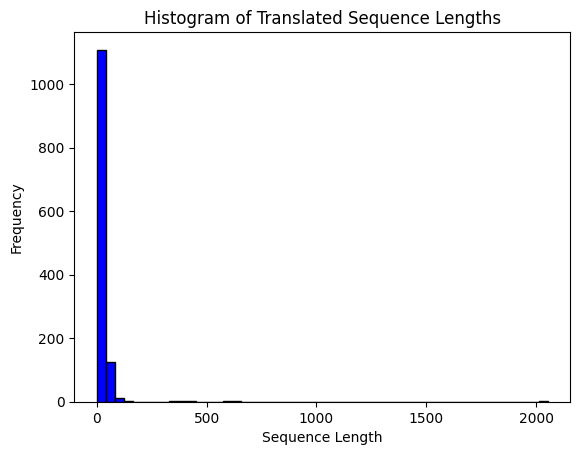

Number of sequences longer than 100 amino acids: 11


In [ ]:
#create a histogram of the lengths of the translated sequences
import matplotlib.pyplot as plt

with open(sixpack_output, 'r') as f:
    sequences = []
    current_seq = ""
    for line in f:
        if line.startswith('>'):
            if current_seq:
                sequences.append(current_seq)
                current_seq = ""
        else:
            current_seq += line.strip()
    if current_seq:
        sequences.append(current_seq)

# Calculate the lengths of the sequences
sequence_lengths = [len(seq) for seq in sequences]

# Plot the histogram
plt.hist(sequence_lengths, bins=50, color='blue', edgecolor='black')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Histogram of Translated Sequence Lengths')
plt.show()

#how many sequences are longer than 100 amino acids
long_sequences = [seq for seq in sequences if len(seq) > 100]
print(f"Number of sequences longer than 100 amino acids: {len(long_sequences)}")

In [ ]:
#put the longer sequences into a new fasta file
long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
with open(long_sequences_fasta, 'w') as f:
    for i, seq in enumerate(long_sequences):
        f.write(f">long_seq_{i}\n")
        f.write(f"{seq}\n")

In [ ]:
#set long_sequences_fasta and output_db for the next step

long_sequences_fasta = os.path.join(output_folder, "oberland_long_sequences.fasta")
output_db = f"{DATAPATH}/ebola_protfams/oberland_long_sequences/oberland_long_sequences_foldseekdb"
os.environ["long_sequences_fasta"] = long_sequences_fasta



In [ ]:
%%bash


MODEL_CKPT="../checkpoints/esm3di_from_mlm/epoch_5.pt"
OUTPUT_ROOT="$DATAPATH/ebola_oberland"

fname="$(basename "$long_sequences_fasta")"
stem="${fname%.*}"
out_dir="$OUTPUT_ROOT/$stem"
mkdir -p "$out_dir"

db_name="${stem}_foldseekdb"
output_db="$out_dir/$db_name"
echo "Running foldseek database creation for $long_sequences_fasta..."


python -m esm3di.fastas2foldseekdb \
    --aa-fasta "$long_sequences_fasta" \
    --model-ckpt "$MODEL_CKPT" \
    --output-db "$output_db" \
	--revision 46c5f7d \
    --keep-fastas

Running foldseek database creation for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...


Checking for FoldSeek installation...
✓ FoldSeek found

Running ESM inference on /home/dmoi/projects/ESM3di/ebola_data/ebola_data/sixpack_results/oberland_long_sequences.fasta...
Using model: ../checkpoints/esm3di_from_mlm/epoch_5.pt
Device: cuda
Loading model configuration from checkpoint...
Using model revision: 46c5f7d
Using 2 GPU(s) for inference on 11 sequences


Multi-GPU inference:   0%|          | 0/2 [00:07<?, ?GPU/s]


Falling back to single-GPU inference...
Using single GPU: cuda
Initializing ESM3DiModel with Synthyra/ESMplusplus_small...

Loading model: Synthyra/ESMplusplus_small


Attention backend: config='sdpa' -> resolved='sdpa'


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 1798.48it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.bias   | MISSING | 
classifier.{0, 2, 3}.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Processed 11/11 sequences
Writing predictions to: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ Prediction complete! 11 sequences written to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_3di.fasta
✓ FASTA files ready

Creating FoldSeek database: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Finished writing Foldseek database to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb
Total sequences: 11
Pep file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb, size: 5072 bytes
TDI file: /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_

In [ ]:
%%bash
output_db="/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/
"
ls -l "$output_db"

total 144
-rw-rw-r-- 1 dmoi dmoi 5072 Aug 21 20:05 oberland_long_sequences_foldseekdb
-rw-rw-r-- 1 dmoi dmoi 5251 Aug 21 20:05 oberland_long_sequences_foldseekdb_3di.fasta
-rw-rw-r-- 1 dmoi dmoi    4 Aug 21 20:05 oberland_long_sequences_foldseekdb.dbtype
-rw-rw-r-- 1 dmoi dmoi  133 Aug 21 20:05 oberland_long_sequences_foldseekdb_h
-rw-rw-r-- 1 dmoi dmoi    4 Aug 21 20:05 oberland_long_sequences_foldseekdb_h.dbtype
-rw-rw-r-- 1 dmoi dmoi   90 Aug 21 20:05 oberland_long_sequences_foldseekdb_h.index
-rw-rw-r-- 1 dmoi dmoi  117 Aug 21 20:05 oberland_long_sequences_foldseekdb.index
-rw-rw-r-- 1 dmoi dmoi  168 Aug 21 20:05 oberland_long_sequences_foldseekdb.lookup
-rw-rw-r-- 1 dmoi dmoi 5072 Aug 21 20:05 oberland_long_sequences_foldseekdb_ss
-rw-rw-r-- 1 dmoi dmoi    4 Aug 21 20:05 oberland_long_sequences_foldseekdb_ss.dbtype
-rw-rw-r-- 1 dmoi dmoi  117 Aug 21 20:05 oberland_long_sequences_foldseekdb_ss.index


In [ ]:
#search against the foldseek databases we made to annotate the unknown ebola proteome
import glob

def run_foldseek( querydb, targetdb, output_folder, foldseekpath = 'foldseek' , maxseqs = 3000):
	'''
	run foldseek search and createtsv
	
	parameters
	----------
	querydb : str
		path to foldseek query database
	targetdb : str 
		path to foldseek target database
	output_folder : str 
		path to output folder
	maxseqs : int   
		maximum number of sequences to compare to

	'''
	if not os.path.exists(output_folder):
		os.makedirs(output_folder)
	

	target_name = os.path.basename(targetdb)
	cmd = f"{foldseekpath} easy-search {querydb} {targetdb} {output_folder}/{target_name}_search.csv tmp --format-output 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits' " 
	subprocess.run(cmd, shell=True, check=True)
	return os.path.join(output_folder, f"{target_name}_search.csv")
output_db="/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb"
querydb = output_db  # The foldseek database created from the unknown ebola proteome
protfam_folders = glob.glob(f"{DATAPATH}/ebola_protfams/*")
for folder in protfam_folders:
	db_files = glob.glob(f"{folder}/*.index")
	if len(db_files) == 0:
		print(f"No .index files found in {folder}. Skipping.")
		continue

	db_path = db_files[0].replace('.index', '')  # Assuming there's only one .index file per folder
	db_path = db_path.replace('_h', '')  # Ensure the path uses forward slashes
	db_path = db_path.replace('_ss', '')  # Ensure the path uses forward slashes
		
	output_folder = os.path.join(folder, "foldseek_search_results_oberland")
	print(f"Running foldseek search for {db_path}...")
	run_foldseek(querydb=querydb, targetdb=db_path, output_folder=output_folder)
	print(f"Search results saved in {output_folder}.")
    

Running foldseek search for /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb...
easy-search /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/foldseek_search_results_oberland/Ebola_NP_cdhit_foldseekdb_search.csv tmp --format-output query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits 

MMseqs Version:                    	10.941cd33
Seq. id. threshold                 	0
Coverage threshold                 	0
Coverage mode                      	0
Max reject                         	2147483647
Max accept                         	2147483647
Add backtrace                      	false
TMscore threshold                  	0
TMscore threshold mode             	0


prefilter /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_oberland/oberland_long_sequences/oberland_long_sequences_foldseekdb_ss /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_NP_cdhit/Ebola_NP_cdhit_foldseekdb_ss tmp/7896082093758221617/search_tmp/9856377168513003848/pref --sub-mat 'aa:3di.out,nucl:3di.out' --seed-sub-mat 'aa:3di.out,nucl:3di.out' -s 9.5 -k 6 --target-search-mode 0 --k-score seq:2147483647,prof:2147483647 --alph-size aa:21,nucl:5 --max-seq-len 65535 --max-seqs 1000 --split 0 --split-mode 2 --split-memory-limit 0 -c 0 --cov-mode 0 --comp-bias-corr 1 --comp-bias-corr-scale 0.15 --diag-score 1 --exact-kmer-matching 0 --mask 0 --mask-prob 0.999995 --mask-lower-case 1 --mask-n-repeat 6 --min-ungapped-score 30 --add-self-matches 0 --spaced-kmer-mode 1 --db-load-mode 0 --pca substitution:1.100,context:1.400 --pcb substitution:4.100,context:5.800 --threads 32 --compressed 0 -v 3 

Query database size: 11 type: Aminoacid
Estimated memory consumpti

In [ ]:
#read off all of the results and make a summary table of the best hits for each query sequence
rescolumns = 'query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits'.split(',')
resfiles = glob.glob(f"{DATAPATH}/ebola_protfams/*/foldseek_search_results_oberland/*.csv")
import pandas as pd

all_results = []
for resfile in resfiles:
    df = pd.read_table(resfile, names=rescolumns, header=None)
    df['source_db'] = os.path.basename(resfile).replace('_search.csv', '')
    all_results.append(df)
all_results_df = pd.concat(all_results, ignore_index=True )
print(f"Total number of hits: {len(all_results_df)}")


Total number of hits: 8917


In [ ]:
all_results_df
#drop evalues greater than 1e-5 and keep the best hit for each query sequence
all_results_df = all_results_df[all_results_df['evalue'] < 1e-5]
#get top 10 for each query sequence
best_hits_df = all_results_df.sort_values('evalue').groupby('query').head(10).reset_index(drop=True)
print(f"Number of best hits after filtering: {len(best_hits_df)}")

NameError: name 'all_results_df' is not defined

In [ ]:
print("Best hits summary:")
print(best_hits_df)

Best hits summary:


NameError: name 'best_hits_df' is not defined

In [ ]:
outdir = f"{DATAPATH}/oberland_results"
if not os.path.exists(outdir):
    os.makedirs(outdir)
output_file = f"{DATAPATH}/oberland_results/best_hits_summary.csv"
best_hits_df.to_csv(output_file, index=False)
print(f"Best hits summary saved to {output_file}")

Best hits summary saved to /home/dmoi/projects/ESM3di/ebola_data/ebola_data/oberland_results/best_hits_summary.csv


In [ ]:
print(DATAPATH)

/home/dmoi/projects/ESM3di/ebola_data/ebola_data


In [ ]:
# take the top hit and clip out the query sequence aligned region and save it to a new fasta file
from Bio import SeqIO

for source in best_hits_df['source_db'].unique():
	source_df = best_hits_df[best_hits_df['source_db'] == source]
	output_fasta = f"{DATAPATH}/oberland_results/Ebola_{source}_top_hits.fasta"
	os.makedirs(os.path.dirname(output_fasta), exist_ok=True)
	with open(output_fasta, 'w') as out_f:
		for _, row in source_df.iterrows():
			query_seq_id = row['query']
			target_seq_id = row['target']
			qstart, qend = int(row['qstart']), int(row['qend'])
			
			# Load the query sequence from the sixpack output
			sixpack_fasta = os.path.join(output_folder, "sixpack_output.fasta")
			for record in SeqIO.parse(sixpack_fasta, "fasta"):
				if record.id == query_seq_id:
					clipped_seq = record.seq[qstart-1:qend]  # Adjust for 0-based indexing
					out_f.write(f">{query_seq_id}|{target_seq_id}\n{clipped_seq}\n")
					break
	print(f"Clipped sequences saved to {output_fasta}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams/Ebola_L/foldseek_search_results_oberland/sixpack_output.fasta'

In [ ]:
#add the found sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.
# Keep only the strongest hit per query


query_to_family = (
	best_hits_df.sort_values("evalue")
	.drop_duplicates("query", keep="first")
	.set_index("query")["source_db"]
	.to_dict()
)

# Create output directory
os.makedirs(f"{DATAPATH}/oberland_results", exist_ok=True)

print(query_to_family)




{'long_seq_5': 'Ebola_GP_cdhit_foldseekdb', 'long_seq_7': 'Ebola_L_foldseekdb', 'long_seq_2': 'Ebola_NP_foldseekdb'}


In [ ]:

# Add sequences to appropriate family files
for query, fam in query_to_family.items():
	if query not in long_sequences:
		continue
	
	# Map foldseekdb names to actual family folder names
	fam_folder = fam.replace("_foldseekdb", "").replace("_cdhit", "")
	fam_folder = '/home/dmoi/projects/ESM3di/ebola_data/ebola_data/Ebola_L_cdhit.fasta'
	fam_fasta_path = f"{DATAPATH}/ebola_protfams/{fam_folder}/{fam_folder}.fasta"
	
	if not os.path.exists(fam_fasta_path):
		print(f"Family fasta {fam_fasta_path} not found. Skipping {query}.")
		continue
	
	output_fasta = f"{DATAPATH}/oberland_results/{fam}_augmented.fasta"
	
	# Append to output file (create if doesn't exist)
	with open(output_fasta, 'a') as f:
		f.write(f">{query}\n{long_sequences[query]}\n")

print("Clipped sequences added to appropriate family files.")

In [ ]:
#let's add these long sequences to the original ebola proteome fasta files and save as a new fasta file. we should add each sequence to its appropriate family fasta file if it has a hit, otherwise we can put it in a separate fasta file for unknown sequences. we can use the best_hits_df to determine which family each long sequence belongs to.


In [ ]:
# Build augmented FASTA inputs for the downsampled tree datasets
import os
import glob
import pandas as pd

best_hits_path = os.path.join(DATAPATH, "oberland_results", "best_hits_summary.csv")
if not os.path.exists(best_hits_path):
    raise FileNotFoundError(f"Best hits summary not found: {best_hits_path}")

best_hits_df = pd.read_csv(best_hits_path)
if "query" not in best_hits_df.columns or "source_db" not in best_hits_df.columns:
    raise ValueError("Expected 'query' and 'source_db' columns in best_hits_summary.csv")

# Keep only the strongest hit per query before assigning it to a family
query_to_family = (
    best_hits_df.sort_values("evalue")
    .drop_duplicates("query", keep="first")
    .set_index("query")["source_db"]
    .to_dict()
)

# Parse the long Oberland sequences into a dict for later merging
long_sequences_fasta = os.path.join(DATAPATH, "sixpack_results", "oberland_long_sequences.fasta")
if not os.path.exists(long_sequences_fasta):
    raise FileNotFoundError(f"Oberland long-sequence FASTA not found: {long_sequences_fasta}")

long_sequences = {}
header = None
with open(long_sequences_fasta, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            header = line[1:].split()[0]
            long_sequences[header] = ""
        elif header is not None:
            long_sequences[header] += line

# Write augmented downsampled family files in a separate folder so the originals stay intact
augmented_root = os.path.join(DATAPATH, "ebola_protfams_downsampled_augmented")
os.makedirs(augmented_root, exist_ok=True)

family_dirs = sorted(glob.glob(os.path.join(DATAPATH, "ebola_protfams", "*"))) + sorted(glob.glob(os.path.join(DATAPATH, "ebola_protfams_cdhit", "*")))
for fam_dir in family_dirs:
    if not os.path.isdir(fam_dir):
        continue
    fam_name = os.path.basename(fam_dir)
    fam_fasta = os.path.join(fam_dir, f"{fam_name}.fasta")
    if not os.path.exists(fam_fasta):
        continue

    # Read the original downsampled family FASTA
    family_sequences = {}
    current_header = None
    with open(fam_fasta, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                current_header = line[1:].split()[0]
                family_sequences[current_header] = ""
            elif current_header is not None:
                family_sequences[current_header] += line

    out_fasta = os.path.join(augmented_root, f"{fam_name}_with_oberland.fasta")
    with open(out_fasta, "w") as out:
        for header, seq in family_sequences.items():
            out.write(f">{header}\n{seq}\n")

        assigned_queries = [q for q, fam in query_to_family.items() if fam == fam_name]
        for q in sorted(set(assigned_queries)):
            if q not in long_sequences:
                continue
            out.write(f">{q}\n{long_sequences[q]}\n")

    print(f"Created augmented tree input for {fam_name}: {len(family_sequences) + len([q for q, fam in query_to_family.items() if fam == fam_name])} sequences")

print(f"Augmented FASTAs saved under {augmented_root}")

# Rebuild the tree inputs list from the augmented downsampled datasets
import os
import glob

augmented_fasta_files = sorted(glob.glob(os.path.join(DATAPATH, "ebola_protfams_downsampled_augmented", "*.fasta")))
print(f"Found {len(augmented_fasta_files)} augmented downsampled FASTA files for tree building.")
for path in augmented_fasta_files[:5]:
    print(path)


Augmented FASTAs saved under /home/dmoi/projects/ESM3di/ebola_data/ebola_data/ebola_protfams_downsampled_augmented
Found 0 augmented downsampled FASTA files for tree building.
